In [1]:
"""
Day 3: Understanding Performance Metrics
Goal: Deep dive into Sharpe, Sortino, Calmar, and other risk metrics
"""

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Imports successful!")
print("📊 Day 3: Understanding Metrics\n")

✅ Imports successful!
📊 Day 3: Understanding Metrics



In [2]:
# Download BTC data
ticker = 'BTC-USD'
start_date = '2020-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')

print(f"Downloading {ticker}...")
df = yf.download(ticker, start=start_date, end=end_date, progress=False)

# Calculate daily returns
df['Returns'] = df['Close'].pct_change()

# Drop NaN
df = df.dropna()

print(f"✅ Downloaded {len(df)} days")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"\nFirst 5 rows:")
df[['Close', 'Returns']].head()

✅ Downloaded 2224 days
Date range: 2020-01-02 to 2026-02-02

First 5 rows:


Price,Close,Returns
Ticker,BTC-USD,
Date,,
2020-01-02,6985.470215,-0.029819
2020-01-03,7344.884277,0.051452
2020-01-04,7410.656738,0.008955
2020-01-05,7411.317383,0.000089
2020-01-06,7769.219238,0.048291


In [5]:
# Calculate Sharpe Ratio step-by-step
print("="*60)
print("SHARPE RATIO CALCULATION")
print("="*60)

# Step 1: Mean daily return
mean_daily_return = df['Returns'].mean()
print(f"\n1. Mean Daily Return: {mean_daily_return:.6f} ({mean_daily_return*100:.4f}%)")

# Step 2: Standard deviation of returns
std_daily_return = df['Returns'].std()
print(f"2. Std Dev of Returns: {std_daily_return:.6f} ({std_daily_return*100:.4f}%)")

# Step 3: Daily Sharpe (assuming risk-free rate = 0)
daily_sharpe = mean_daily_return / std_daily_return
print(f"3. Daily Sharpe: {daily_sharpe:.6f}")

# Step 4: Annualized Sharpe
# Note: Using 365 days for crypto (markets open 24/7/365)
# Traditional stocks use 252 days (markets closed on weekends/holidays)
annual_sharpe = daily_sharpe * np.sqrt(365)
print(f"4. Annualized Sharpe (365 days): {annual_sharpe:.4f}")

print(f"\n{'='*60}")
print(f"SHARPE RATIO SUMMARY:")
print(f"  Daily Sharpe:  {daily_sharpe:.6f}")
print(f"  Annual Sharpe: {annual_sharpe:.4f}")
print(f"\n{'='*60}")
print(f"INTERPRETATION:")
if annual_sharpe < 0:
    print("❌ Negative: Losing money")
elif annual_sharpe < 1:
    print("⚠️  < 1.0: Poor risk-adjusted returns")
elif annual_sharpe < 2:
    print("✅ 1.0-2.0: Good risk-adjusted returns")
else:
    print("🏆 > 2.0: Excellent risk-adjusted returns")
print("="*60)

SHARPE RATIO CALCULATION

1. Mean Daily Return: 0.001590 (0.1590%)
2. Std Dev of Returns: 0.031792 (3.1792%)
3. Daily Sharpe: 0.050006
4. Annualized Sharpe (365 days): 0.9554

SHARPE RATIO SUMMARY:
  Daily Sharpe:  0.050006
  Annual Sharpe: 0.9554

INTERPRETATION:
⚠️  < 1.0: Poor risk-adjusted returns


In [6]:
# Calculate Sortino Ratio (only penalizes downside volatility)
print("="*60)
print("SORTINO RATIO CALCULATION")
print("="*60)

# Step 1: Separate downside returns (negative only)
downside_returns = df['Returns'][df['Returns'] < 0]

print(f"\n1. Total returns: {len(df['Returns'])}")
print(f"   Downside returns (negative): {len(downside_returns)}")
print(f"   Upside returns (positive): {len(df['Returns']) - len(downside_returns)}")

# Step 2: Calculate downside deviation
downside_std = downside_returns.std()
print(f"\n2. Downside Std Dev: {downside_std:.6f}")
print(f"   (Compare to total std: {std_daily_return:.6f})")

# Step 3: Daily Sortino
daily_sortino = mean_daily_return / downside_std
print(f"\n3. Daily Sortino: {daily_sortino:.6f}")

# Step 4: Annualized Sortino (365 days for crypto)
annual_sortino = daily_sortino * np.sqrt(365)
print(f"4. Annual Sortino (365 days): {annual_sortino:.4f}")

print(f"\n{'='*60}")
print(f"SORTINO RATIO SUMMARY:")
print(f"  Daily Sortino:  {daily_sortino:.6f}")
print(f"  Annual Sortino: {annual_sortino:.4f}")
print(f"\n{'='*60}")
print(f"COMPARISON:")
print(f"  Sharpe:  {annual_sharpe:.4f} (penalizes all volatility)")
print(f"  Sortino: {annual_sortino:.4f} (penalizes only downside)")
print(f"\n  Sortino / Sharpe Ratio: {annual_sortino / annual_sharpe:.2f}x")
print(f"  → Higher = More positive skew (big wins, small losses)")
print("="*60)

SORTINO RATIO CALCULATION

1. Total returns: 2224
   Downside returns (negative): 1091
   Upside returns (positive): 1133

2. Downside Std Dev: 0.023678
   (Compare to total std: 0.031792)

3. Daily Sortino: 0.067141
4. Annual Sortino (365 days): 1.2827

SORTINO RATIO SUMMARY:
  Daily Sortino:  0.067141
  Annual Sortino: 1.2827

COMPARISON:
  Sharpe:  0.9554 (penalizes all volatility)
  Sortino: 1.2827 (penalizes only downside)

  Sortino / Sharpe Ratio: 1.34x
  → Higher = More positive skew (big wins, small losses)


In [7]:
# Calculate Calmar Ratio (Return / Max Drawdown)
print("="*60)
print("CALMAR RATIO CALCULATION")
print("="*60)

# Step 1: Calculate cumulative returns
cumulative_returns = (1 + df['Returns']).cumprod()

# Step 2: Calculate running maximum (peak value at each point)
running_max = cumulative_returns.cummax()

# Step 3: Calculate drawdown at each point
# Drawdown = (Current Value - Peak Value) / Peak Value
drawdown = (cumulative_returns - running_max) / running_max

# Step 4: Find maximum drawdown (most negative value)
max_drawdown = drawdown.min()
max_drawdown_pct = max_drawdown * 100

print(f"\n1. Maximum Drawdown: {max_drawdown_pct:.2f}%")

# Step 5: Calculate total return
total_return = cumulative_returns.iloc[-1] - 1
total_return_pct = total_return * 100

print(f"2. Total Return: {total_return_pct:.2f}%")

# Step 6: Annualize the return
years = len(df) / 365
annual_return = ((1 + total_return) ** (1 / years)) - 1
annual_return_pct = annual_return * 100

print(f"3. Period: {years:.2f} years")
print(f"4. Annualized Return: {annual_return_pct:.2f}%")

# Step 7: Calculate Calmar Ratio
calmar_ratio = annual_return_pct / abs(max_drawdown_pct)

print(f"\n{'='*60}")
print(f"CALMAR RATIO CALCULATION:")
print(f"  Annual Return: {annual_return_pct:.2f}%")
print(f"  Max Drawdown:  {max_drawdown_pct:.2f}%")
print(f"  Calmar Ratio:  {calmar_ratio:.4f}")
print(f"\n{'='*60}")
print(f"INTERPRETATION:")
if calmar_ratio < 0.5:
    print("❌ < 0.5: High drawdown relative to returns")
elif calmar_ratio < 1.0:
    print("⚠️  0.5-1.0: Moderate pain for the returns")
elif calmar_ratio < 2.0:
    print("✅ 1.0-2.0: Good return per unit of max pain")
else:
    print("🏆 > 2.0: Excellent - low drawdown, high returns")
print(f"\nMeaning: You earned {calmar_ratio:.2f}% annual return")
print(f"         for every 1% of maximum drawdown suffered")
print("="*60)


CALMAR RATIO CALCULATION

1. Maximum Drawdown: -76.63%
2. Total Return: 992.87%
3. Period: 6.09 years
4. Annualized Return: 48.06%

CALMAR RATIO CALCULATION:
  Annual Return: 48.06%
  Max Drawdown:  -76.63%
  Calmar Ratio:  0.6272

INTERPRETATION:
⚠️  0.5-1.0: Moderate pain for the returns

Meaning: You earned 0.63% annual return
         for every 1% of maximum drawdown suffered


In [8]:
# Create comprehensive metrics summary
print("="*60)
print("COMPREHENSIVE PERFORMANCE METRICS SUMMARY")
print("="*60)
print(f"\nData: {ticker}")
print(f"Period: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Duration: {years:.2f} years ({len(df)} days)")

print(f"\n{'='*60}")
print("RETURN METRICS:")
print(f"{'='*60}")
print(f"Total Return:      {total_return_pct:>10.2f}%")
print(f"Annualized Return: {annual_return_pct:>10.2f}%")
print(f"Daily Avg Return:  {mean_daily_return*100:>10.4f}%")

print(f"\n{'='*60}")
print("RISK METRICS:")
print(f"{'='*60}")
print(f"Daily Volatility:     {std_daily_return*100:>10.4f}%")
print(f"Downside Volatility:  {downside_std*100:>10.4f}%")
print(f"Maximum Drawdown:     {max_drawdown_pct:>10.2f}%")

print(f"\n{'='*60}")
print("RISK-ADJUSTED METRICS:")
print(f"{'='*60}")
print(f"Sharpe Ratio:")
print(f"  Daily:              {daily_sharpe:>10.6f}")
print(f"  Annual (365 days):  {annual_sharpe:>10.4f}")
print(f"\nSortino Ratio:")
print(f"  Daily:              {daily_sortino:>10.6f}")
print(f"  Annual (365 days):  {annual_sortino:>10.4f}")
print(f"\nCalmar Ratio:         {calmar_ratio:>10.4f}")

print(f"\n{'='*60}")
print("WIN/LOSS STATISTICS:")
print(f"{'='*60}")
winning_days = len(df[df['Returns'] > 0])
losing_days = len(df[df['Returns'] < 0])
win_rate = (winning_days / len(df)) * 100

print(f"Winning Days:         {winning_days:>10} ({win_rate:.2f}%)")
print(f"Losing Days:          {losing_days:>10} ({100-win_rate:.2f}%)")

print(f"\n{'='*60}")
print("METRIC RATIOS (Insight into Return Distribution):")
print(f"{'='*60}")
print(f"Sortino / Sharpe:     {annual_sortino/annual_sharpe:>10.2f}x")
print(f"  → Higher = More positive skew")
print(f"  → {annual_sortino/annual_sharpe:.2f}x means upside volatility dominates")

print(f"\nDownside / Total Vol: {downside_std/std_daily_return:>10.2f}x")
print(f"  → Lower = Losses are more controlled")
print(f"  → {downside_std/std_daily_return:.2f}x means downside is {(1-downside_std/std_daily_return)*100:.1f}% calmer")

print("="*60)

COMPREHENSIVE PERFORMANCE METRICS SUMMARY

Data: BTC-USD
Period: 2020-01-02 to 2026-02-02
Duration: 6.09 years (2224 days)

RETURN METRICS:
Total Return:          992.87%
Annualized Return:      48.06%
Daily Avg Return:      0.1590%

RISK METRICS:
Daily Volatility:         3.1792%
Downside Volatility:      2.3678%
Maximum Drawdown:         -76.63%

RISK-ADJUSTED METRICS:
Sharpe Ratio:
  Daily:                0.050006
  Annual (365 days):      0.9554

Sortino Ratio:
  Daily:                0.067141
  Annual (365 days):      1.2827

Calmar Ratio:             0.6272

WIN/LOSS STATISTICS:
Winning Days:               1133 (50.94%)
Losing Days:                1091 (49.06%)

METRIC RATIOS (Insight into Return Distribution):
Sortino / Sharpe:           1.34x
  → Higher = More positive skew
  → 1.34x means upside volatility dominates

Downside / Total Vol:       0.74x
  → Lower = Losses are more controlled
  → 0.74x means downside is 25.5% calmer


✅ Drawdown chart saved!


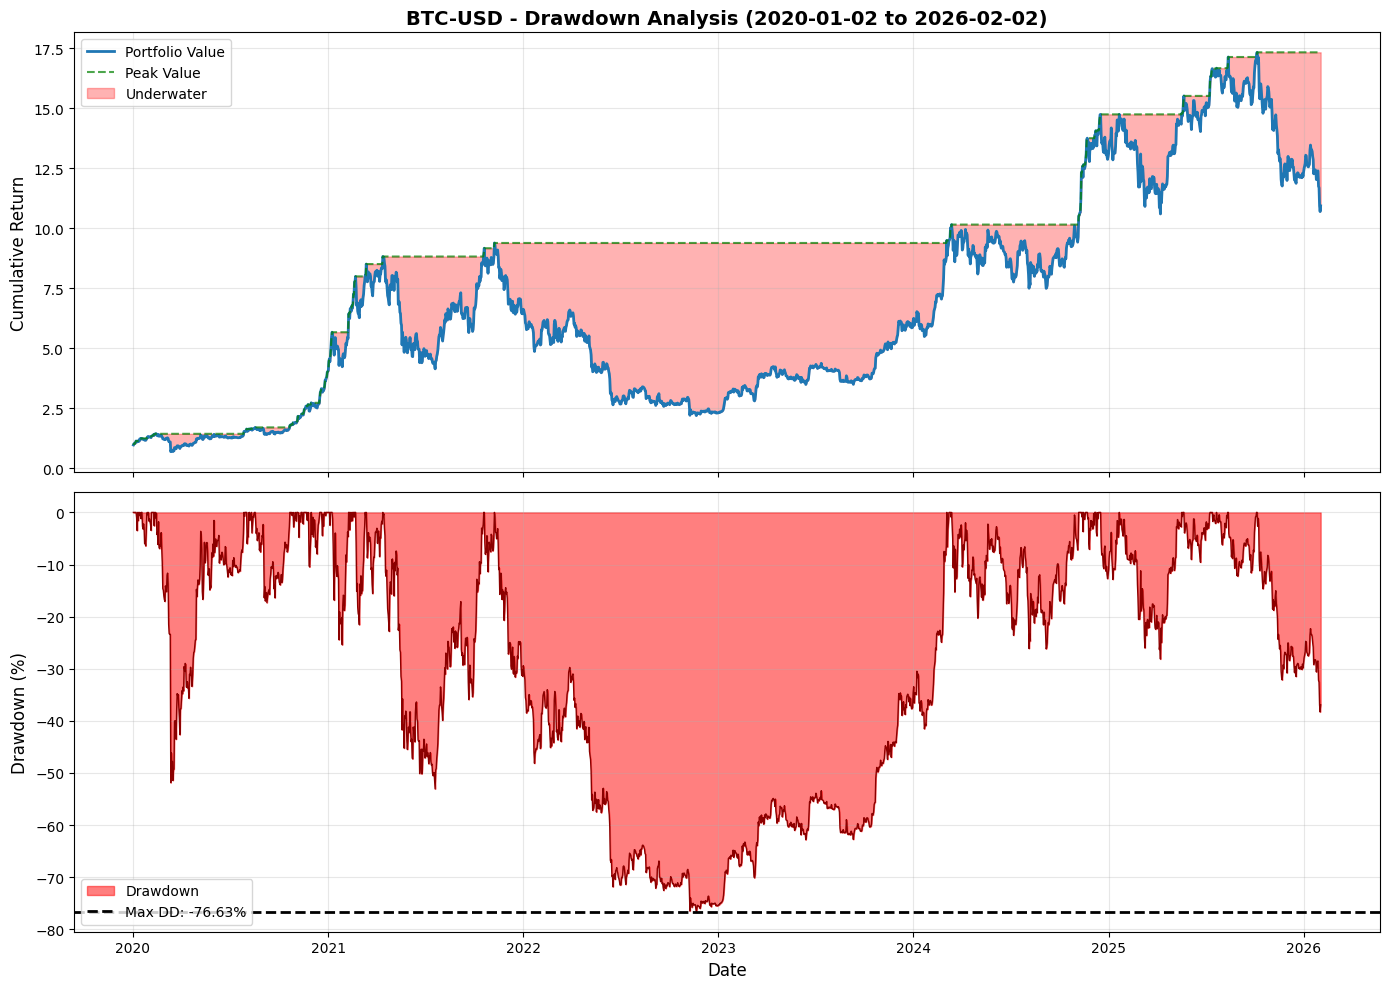


WORST DRAWDOWN DETAILS:
Date of max drawdown: 2022-11-21
Drawdown: -76.63%
This means you were 76.63% below your peak value


In [9]:
# Visualize the drawdown curve
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel 1: Cumulative returns with running max
ax1.plot(df.index, cumulative_returns, label='Portfolio Value', linewidth=2)
ax1.plot(df.index, running_max, label='Peak Value', 
         linestyle='--', alpha=0.7, linewidth=1.5, color='green')
ax1.fill_between(df.index, cumulative_returns, running_max, 
                  alpha=0.3, color='red', label='Underwater')
ax1.set_ylabel('Cumulative Return', fontsize=12)
ax1.set_title(f'{ticker} - Drawdown Analysis ({df.index[0].date()} to {df.index[-1].date()})', 
              fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Panel 2: Drawdown percentage
ax2.fill_between(df.index, 0, drawdown * 100, 
                  alpha=0.5, color='red', label='Drawdown')
ax2.plot(df.index, drawdown * 100, color='darkred', linewidth=1)
ax2.axhline(y=max_drawdown_pct, color='black', 
            linestyle='--', linewidth=2, label=f'Max DD: {max_drawdown_pct:.2f}%')
ax2.set_ylabel('Drawdown (%)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('drawdown_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Drawdown chart saved!")
plt.show()

# Find the worst drawdown period
max_dd_date = drawdown.idxmin()
max_dd_value = drawdown.min() * 100

print(f"\n{'='*60}")
print(f"WORST DRAWDOWN DETAILS:")
print(f"{'='*60}")
print(f"Date of max drawdown: {max_dd_date.date()}")
print(f"Drawdown: {max_dd_value:.2f}%")
print(f"This means you were {abs(max_dd_value):.2f}% below your peak value")
print("="*60)